# SHAP ANALYZER

In [1]:
import shap
import numpy as np
import pandas as pd



def analyze_with_shap(model, X_train, sample):
    if isinstance(sample, pd.Series):
        sample = sample.to_frame().T
    
    predicted_class = int(model.predict(sample)[0])
    model_type = str(type(model)).lower()
    feature_names = list(X_train.columns)
    
    try:
        if any(t in model_type for t in ["forest", "tree", "boost", "gbm", "catboost"]):
            explainer = shap.TreeExplainer(model)
            raw = explainer.shap_values(sample)
        elif any(t in model_type for t in ["keras", "tensorflow", "torch"]):
            background = shap.sample(X_train, min(100, len(X_train))).values
            explainer = shap.DeepExplainer(model, background)
            raw = explainer.shap_values(sample.values)
        else:
            explainer = shap.Explainer(model, X_train)
            res = explainer(sample)
            raw = res.values if hasattr(res, "values") else res
    except Exception:
        background = shap.sample(X_train, min(50, len(X_train)))
        explainer = shap.KernelExplainer(model.predict_proba, background)
        raw = explainer.shap_values(sample)

    if isinstance(raw, list):
        vals = raw[predicted_class]
    else:
        vals = np.array(raw)

    if vals.ndim == 3:         
        vals = vals[0, :, predicted_class]
    elif vals.ndim == 2:         
        vals = vals[0]
    
    shap_dict = {name: float(val) for name, val in zip(feature_names, vals)}
    sample_dict = {name: float(sample[name].iloc[0]) for name in feature_names}

    return shap_dict, sample_dict, predicted_class

# EXPERT SYSTEM

In [2]:
import collections
import collections.abc
for _attr in ("Mapping", "MutableMapping", "Sequence"):
    if not hasattr(collections, _attr):
        setattr(collections, _attr, getattr(collections.abc, _attr))

from experta import KnowledgeEngine, Fact, Rule, Field, MATCH
import shap
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

MEDICAL_METADATA = {
    "systolic_bp": {
        "unit": "mmHg",
        "group": "Vitals",
        "arabic_name": "ضغط الدم الانقباضي",
        "ranges": {
            "default": "90-120",
            "elderly": "90-130",
            "diabetic": "90-130"  
        }
    },
    "ldl_cholesterol": {
        "unit": "mg/dL",
        "group": "Labs",
        "arabic_name": "الكوليسترول الضار (LDL)",
        "ranges": {
            "default": "<100",
            "diabetic": "<70"     
        }
    },
    "creatinine": {
        "unit": "mg/dL",
        "group": "Labs",
        "arabic_name": "الكرياتينين في الدم",
        "ranges": {
            "male": "0.7-1.3",
            "female": "0.6-1.1",
            "default": "0.6-1.2"
        }
    },
    "urea": {
        "unit": "mg/dL",
        "group": "Labs",
        "arabic_name": "اليوريا في الدم",
        "ranges": {
            "default": "7-20"
        }
    },
    "glucose": {
        "unit": "mg/dL",
        "group": "Labs",
        "arabic_name": "جلوكوز الدم الصائم",
        "ranges": {
            "default": "70-100",
            "diabetic": "80-130" 
            }
    },
    "heart_rate": {
        "unit": "bpm",
        "group": "Vitals",
        "arabic_name": "معدل ضربات القلب",
        "ranges": {
            "default": "60-100"
        }
    },
}

def parse_clinical_status(value, range_str):
    if not range_str:
        return "Normal"
    range_str = range_str.strip()
    try:
        if range_str.startswith("<="):
            limit = float(range_str[2:])
            return "Normal" if value <= limit else "High"
        elif range_str.startswith("<"):
            limit = float(range_str[1:])
            return "Normal" if value < limit else "High"
        elif range_str.startswith(">="):
            limit = float(range_str[2:])
            return "Normal" if value >= limit else "Low"
        elif range_str.startswith(">"):
            limit = float(range_str[1:])
            return "Normal" if value > limit else "Low"
        elif "-" in range_str:
            parts = range_str.split("-")
            low = float(parts[0])
            high = float(parts[1])
            if value < low:
                return "Low"
            elif value > high:
                return "High"
            else:
                return "Normal"
    except ValueError:
        pass
    return "Normal"


class PatientContext(Fact):
    age = Field(int, mandatory=True)
    gender = Field(str, mandatory=True) 
    comorbidities = Field(list, default=[])


class FeaturesFact(Fact):
    feature_name = Field(str, mandatory=True)
    raw_name = Field(str, mandatory=True)
    value = Field(float, mandatory=True)
    unit = Field(str, default="")
    normal_range = Field(str, default="")
    clinical_status = Field(str, default="Normal")
    group = Field(str, default="General")
    shap_value = Field(float, mandatory=True)
    importance_level = Field(str, mandatory=True)
    direction = Field(str, mandatory=True)


class MedicalExpertSystem(KnowledgeEngine):
    def __init__(self):
        super().__init__()
        self.explanations = []
        self.clinical_insights = []

    @Rule(FeaturesFact(feature_name=MATCH.f,
                       value=MATCH.val,
                       unit=MATCH.u,
                       normal_range=MATCH.nr,
                       shap_value=MATCH.v,
                       importance_level="High",
                       direction="Positive",
                       clinical_status="High"))
    def rule_high_risk_factor_confirmed(self, f, val, u, nr, v):
        ref = f" [المعدل الطبيعي المرجعي المخصص: {nr} {u}]" if nr else ""
        self.explanations.append(
            f"• يمثل مؤشر '{f}' بقيمته المسجلة المرتفعة ({val} {u}){ref} عامل خطورة مرتفع الأثر، "
            f"مما يدعم هذا التنبؤ الطبي سريرياً باتساق كامل مع المعايير الطبية المرجعية."
        )

    @Rule(FeaturesFact(feature_name=MATCH.f,
                       value=MATCH.val,
                       unit=MATCH.u,
                       normal_range=MATCH.nr,
                       shap_value=MATCH.v,
                       importance_level="High",
                       direction="Positive",
                       clinical_status="Normal"))
    def rule_high_risk_factor_unconfirmed(self, f, val, u, nr, v):
        ref = f" [المعدل الطبيعي المرجعي المخصص: {nr} {u}]" if nr else ""
        self.explanations.append(
            f"• يمثل مؤشر '{f}' بقيمته المسجلة ({val} {u}){ref} مساهماً بارزاً في توجيه نموذج الذكاء الاصطناعي، "
            f"على الرغم من كونه يقع ضمن الحدود الطبيعية سريرياً."
        )

    @Rule(FeaturesFact(feature_name=MATCH.f,
                       value=MATCH.val,
                       unit=MATCH.u,
                       normal_range=MATCH.nr,
                       shap_value=MATCH.v,
                       importance_level="High",
                       direction="Negative"))
    def rule_high_protective_factor(self, f, val, u, nr, v):
        ref = f" [المعدل الطبيعي المرجعي المخصص: {nr} {u}]" if nr else ""
        self.explanations.append(
            f"• يمثل مؤشر '{f}' بقيمته المسجلة ({val} {u}){ref} مؤشراً مطمئناً قوي الأثر (عامل حماية)، "
            f"ويسهم بوضوح في خفض احتمالية الإصابة أو استبعاد التنبؤ الحالي."
        )

    @Rule(FeaturesFact(feature_name=MATCH.f,
                       value=MATCH.val,
                       unit=MATCH.u,
                       normal_range=MATCH.nr,
                       shap_value=MATCH.v,
                       importance_level="Medium",
                       direction="Positive"))
    def rule_medium_risk_factor(self, f, val, u, nr, v):
        ref = f" [المعدل الطبيعي المرجعي المخصص: {nr} {u}]" if nr else ""
        self.explanations.append(
            f"• يظهر مؤشر '{f}' بقيمته المسجلة ({val} {u}){ref} كعامل خطورة متوسط ومساهم في القرار الحالي."
        )

    @Rule(FeaturesFact(feature_name=MATCH.f,
                       value=MATCH.val,
                       unit=MATCH.u,
                       normal_range=MATCH.nr,
                       shap_value=MATCH.v,
                       importance_level="Medium",
                       direction="Negative"))
    def rule_medium_protective_factor(self, f, val, u, nr, v):
        ref = f" [المعدل الطبيعي المرجعي المخصص: {nr} {u}]" if nr else ""
        self.explanations.append(
            f"• يمثل مؤشر '{f}' بقيمته المسجلة ({val} {u}){ref} مؤشراً مطمئناً متوسط المساهمة."
        )

    @Rule(FeaturesFact(feature_name=MATCH.f,
                       value=MATCH.val,
                       unit=MATCH.u,
                       shap_value=MATCH.v,
                       importance_level="Low"))
    def rule_low_impact_factor(self, f, val, u, v):
        self.explanations.append(
            f"• مؤشر '{f}' بقيمته الحالية ({val} {u}) ذو تأثير محدود وغير حاسم في مسار القرار السريري الحالي."
        )

    @Rule(
        FeaturesFact(group="Vitals", raw_name=MATCH.rn1, direction="Positive", importance_level="High"),
        FeaturesFact(group="Labs", raw_name=MATCH.rn2, direction="Positive", importance_level="High")
    )
    def check_cardio_synergy(self, rn1, rn2):
        bp_list = ["systolic_bp", "blood_pressure"]
        chol_list = ["ldl_cholesterol", "cholesterol"]
        is_bp = rn1 in bp_list or rn2 in bp_list
        is_chol = rn1 in chol_list or rn2 in chol_list
        if is_bp and is_chol:
            self.clinical_insights.append(
                " [تحذير سريري]: لوحظ تأثير تآزري سلبي ناتج عن التزامن بين ارتفاع ضغط الدم الشرياني وارتفاع الكوليسترول الضار، "
                "مما يزيد بشكل مضاعف من مخاطر الحوادث القلبية والوعائية مقارنة بوجود عامل منفرد."
            )

    @Rule(
        FeaturesFact(group="Labs", raw_name=MATCH.rn1, direction="Positive", importance_level="High"),
        FeaturesFact(group="Labs", raw_name=MATCH.rn2, direction="Positive", importance_level="High")
    )
    def check_renal_synergy(self, rn1, rn2):
        if rn1 != rn2:
            is_creat = rn1 == "creatinine" or rn2 == "creatinine"
            is_urea = rn1 == "urea" or rn2 == "urea"
            if is_creat and is_urea:
                self.clinical_insights.append(
                    " [تحذير سريري]: يظهر الارتفاع المشترك والبارز في الكرياتينين واليوريا كدلالة قوية "
                    "على احتمالية وجود تراجع ملحوظ في معدل الترشيح الكبيبي والوظيفة الكلوية للحالة."
                )

    @Rule(
        PatientContext(comorbidities=MATCH.comor),
        FeaturesFact(raw_name="systolic_bp", value=MATCH.val, direction="Positive", importance_level="High")
    )
    def check_diabetic_hypertension_context(self, comor, val):
        if "diabetes" in comor:
            self.clinical_insights.append(
                f" [تنبيه خاص بالسكري]: إن رصد ارتفاع ضغط الدم الانقباضي بمستوى ({val} mmHg) "
                f"يمثل تهديداً متزايداً للإصابة باعتلال الشبكية والكلية لدى مرضى السكري بشكل خاص، "
                f"ويتطلب خطة علاجية مستهدفة لضبط الضغط في مستويات أدنى."
            )

    @Rule(
        PatientContext(age=MATCH.age),
        FeaturesFact(raw_name="ldl_cholesterol", value=MATCH.val, direction="Positive", importance_level="High")
    )
    def check_elderly_cholesterol_context(self, age, val):
        if age > 65:
            self.clinical_insights.append(
                f" [تنبيه سريري لفئة كبار السن]: المريض يبلغ من العمر ({age} عاماً) ولديه ارتفاع "
                f"في مؤشر LDL بمقدار ({val} mg/dL). يتطلب التدخل الدوائي عناية خاصة لضمان موازنة الفوائد "
                f"مقابل الآثار الجانبية للأدوية الخافضة للدهون."
            )


def classify_features_clinical(shap_dict, sample_dict, patient_context, high_ratio=0.20, med_ratio=0.05):
    total = sum(abs(v) for v in shap_dict.values()) or 1e-9
    classified = []
    
    age = patient_context.get("age", 40)
    gender = patient_context.get("gender", "male")
    comorbidities = patient_context.get("comorbidities", [])

    for name, val in shap_dict.items():
        ratio = abs(val) / total
        if ratio >= high_ratio:
            level = "High"
        elif ratio >= med_ratio:
            level = "Medium"
        else:
            level = "Low"
            
        direction = "Positive" if val >= 0 else "Negative"
        
        meta = MEDICAL_METADATA.get(name.lower(), {})
        arabic_name = meta.get("arabic_name", name.replace("_", " ").title())
        unit = meta.get("unit", "")
        group = meta.get("group", "General")
        ranges = meta.get("ranges", {})
        
        if "diabetes" in comorbidities and "diabetic" in ranges:
            normal_range = ranges["diabetic"]
        elif age > 65 and "elderly" in ranges:
            normal_range = ranges["elderly"]
        elif gender in ranges:
            normal_range = ranges[gender]
        else:
            normal_range = ranges.get("default", "")
        
        raw_val = float(sample_dict.get(name, 0.0))
        clinical_status = parse_clinical_status(raw_val, normal_range)
        
        classified.append({
            "feature_name": arabic_name,
            "raw_name": name.lower(),
            "value": raw_val,
            "unit": unit,
            "normal_range": normal_range,
            "clinical_status": clinical_status,
            "group": group,
            "shap_value": float(val),
            "importance_level": level,
            "direction": direction,
            "ratio": ratio
        })
        
    return classified


def generate_arabic_medical_report(shap_dict, sample_dict, predicted_class, patient_context, class_names=None):
    classified = classify_features_clinical(shap_dict, sample_dict, patient_context)
    
    engine = MedicalExpertSystem()
    engine.reset()    
    engine.declare(PatientContext(
        age=patient_context.get("age", 40),
        gender=patient_context.get("gender", "male"),
        comorbidities=patient_context.get("comorbidities", [])
    ))    
    for item in sorted(classified, key=lambda x: -x["ratio"]):
        engine.declare(FeaturesFact(
            feature_name=item["feature_name"],
            raw_name=item["raw_name"],
            value=item["value"],
            unit=item["unit"],
            normal_range=item["normal_range"],
            clinical_status=item["clinical_status"],
            group=item["group"],
            shap_value=item["shap_value"],
            importance_level=item["importance_level"],
            direction=item["direction"]
        ))
        
    engine.run()
    
    label = (class_names[predicted_class] if class_names is not None else str(predicted_class))
    
    high_feats = [c for c in classified if c["importance_level"] == "High"]
    risk_high = [c for c in high_feats if c["direction"] == "Positive"]
    prot_high = [c for c in high_feats if c["direction"] == "Negative"]
    
    summary_section = (
        f"التقرير التشخيصي الاستشاري المساعد لبيانات المريض\n"
        f"============================================\n"
        f" التشخيص المرجح من النموذج: « {label} »\n"
        f" العمر: {patient_context.get('age')} | الجنس: {patient_context.get('gender')} | الأمراض المصاحبة: {', '.join(patient_context.get('comorbidities', [])) or 'لا يوجد'}\n"
        f" فحص المؤشرات المؤثرة:\n"
        f"  - عوامل خطورة عالية الأثر: {len(risk_high)}\n"
        f"  - مؤشرات مطمئنة عالية التأثير: {len(prot_high)}\n"
        f"  - مؤشرات متوسطة التأثير: {sum(1 for c in classified if c['importance_level']=='Medium')}\n"
        f"  - مؤشرات طفيفة الأثر: {sum(1 for c in classified if c['importance_level']=='Low')}"
    )
    analysis_section = ["\n تحليل المعطيات الحيوية والمخبرية للمريض:"]
    analysis_section.extend(engine.explanations)
    synergy_section = []
    if engine.clinical_insights:
        synergy_section.append("\n تنبيهات سريرية ناتجة عن سياق المريض وتفاعل المؤشرات:")
        synergy_section.extend(engine.clinical_insights)

    sections = [summary_section, "\n".join(analysis_section)]
    if synergy_section:
        sections.append("\n".join(synergy_section))
    
    return "\n\n".join(sections)


def displaychart(classified_data, model_title):
    features = sorted(classified_data, key=lambda x: abs(x["ratio"]), reverse=True)[:8]
    
    feature_names = []
    shap_values = []
    bar_colors = []
    annotations = []

    for item in features:
        display_label = f"{item['raw_name'].upper()}\n({item['value']:.2f} {item['unit']})"
        feature_names.append(display_label)
        shap_values.append(item["shap_value"])
        
        if item["direction"] == "Positive":
            if item["clinical_status"] == "High":
                bar_colors.append("#d9534f") 
            else:
                bar_colors.append("#f0ad4e") 
        else:
            bar_colors.append("#5cb85c")      

        ref_range = f"[{item['normal_range']}]" if item['normal_range'] else ""
        annotations.append(f" {item['clinical_status']} {ref_range}")
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(10, len(features) * 0.75))
    bars = ax.barh(feature_names, shap_values, color=bar_colors, edgecolor="#444444", height=0.55)
    ax.axvline(x=0, color="#333333", linestyle="--", linewidth=1.2)
    max_val = max(np.abs(shap_values)) if shap_values else 1.0
    for bar, ann, val in zip(bars, annotations, shap_values):
        width = bar.get_width()
        offset = max_val * 0.02
        if val >= 0:
            ax.text(width + offset, bar.get_y() + bar.get_height()/2, 
                    ann, ha='left', va='center', fontsize=9, fontweight='bold', color='#333333')
        else:
            ax.text(width - offset, bar.get_y() + bar.get_height()/2, 
                    ann, ha='right', va='center', fontsize=9, fontweight='bold', color='#333333')

    ax.set_title(f"Diagnostic Value Contributions - {model_title}", fontsize=13, pad=15, fontweight="bold")
    ax.set_xlabel("← Reduces Target Class Probability  |  Increases Target Class Probability →", fontsize=9, labelpad=8)
    ax.set_xlim(-max_val * 1.5, max_val * 1.5)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()


def display_interactiveChart(classified_data, model_title):
    features = sorted(classified_data, key=lambda x: abs(x["ratio"]), reverse=True)[:8]
    features.reverse()  
    y_labels = [f"{item['raw_name'].upper()} ({item['value']:.2f} {item['unit']})" for item in features]
    shap_values = [item["shap_value"] for item in features]
    colors = []
    hover_texts = []
    for item in features:
        if item["direction"] == "Positive":
            color = "#d9534f" if item["clinical_status"] == "High" else "#f0ad4e"
        else:
            color = "#5cb85c"
        colors.append(color)
        hover_info = (
            f"<b>Parameter:</b> {item['raw_name'].upper()}<br>"
            f"<b>Value:</b> {item['value']:.2f} {item['unit']}<br>"
            f"<b>Clinical Status:</b> {item['clinical_status']}<br>"
            f"<b>Reference Bound:</b> {item['normal_range'] if item['normal_range'] else 'N/A'}<br>"
            f"<b>Impact Value:</b> {item['shap_value']:.4f}"
        )
        hover_texts.append(hover_info)
    fig = go.Figure()
    fig.add_trace(go.Bar(
        y=y_labels,
        x=shap_values,
        orientation='h',
        marker=dict(color=colors, line=dict(color='#444444', width=1)),
        hovertext=hover_texts,
        hoverinfo="text"
    ))
    fig.update_layout(
        title=dict(
            text=f"Model Feature Explanations - {model_title}",
            x=0.05,
            y=0.95,
            font=dict(size=15, color="#2c3e50")
        ),
        xaxis=dict(
            title="← Reduces Predicted Target Class Value  |  Increases Target Value →",
            zeroline=True,
            zerolinecolor="#2c3e50",
            zerolinewidth=1.2,
            gridcolor="#f0f2f5"
        ),
        yaxis=dict(gridcolor="#f0f2f5"),
        plot_bgcolor="#ffffff",
        paper_bgcolor="#ffffff",
        margin=dict(l=150, r=50, t=80, b=50),
        height=380,
        showlegend=False
    )
    fig.show()

# MAIN

1. Tree-Based Model (RandomForestClassifier)
التقرير التشخيصي الاستشاري المساعد لبيانات المريض
 التشخيص المرجح من النموذج: « class_0 »
 العمر: 67 | الجنس: male | الأمراض المصاحبة: diabetes
 فحص المؤشرات المؤثرة:
  - عوامل خطورة عالية الأثر: 1
  - مؤشرات مطمئنة عالية التأثير: 0
  - مؤشرات متوسطة التأثير: 6
  - مؤشرات طفيفة الأثر: 6


 تحليل المعطيات الحيوية والمخبرية للمريض:
• مؤشر 'Malic Acid' بقيمته الحالية (3.1 ) ذو تأثير محدود وغير حاسم في مسار القرار السريري الحالي.
• مؤشر 'Ash' بقيمته الحالية (2.56 ) ذو تأثير محدود وغير حاسم في مسار القرار السريري الحالي.
• مؤشر 'Nonflavanoid Phenols' بقيمته الحالية (0.17 ) ذو تأثير محدود وغير حاسم في مسار القرار السريري الحالي.
• مؤشر 'Proanthocyanins' بقيمته الحالية (1.66 ) ذو تأثير محدود وغير حاسم في مسار القرار السريري الحالي.
• مؤشر 'Total Phenols' بقيمته الحالية (2.7 ) ذو تأثير محدود وغير حاسم في مسار القرار السريري الحالي.
• مؤشر 'Magnesium' بقيمته الحالية (116.0 ) ذو تأثير محدود وغير حاسم في مسار القرار السريري الحالي.
• يظهر مؤشر 'Hue' بق

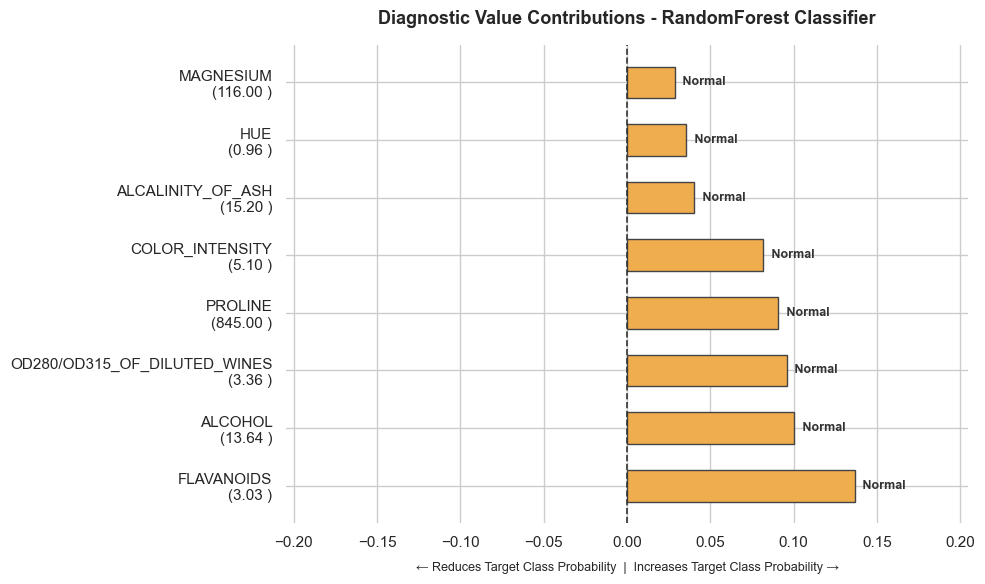


2. Linear Model (Logistic Regression)
التقرير التشخيصي الاستشاري المساعد لبيانات المريض
 التشخيص المرجح من النموذج: « class_0 »
 العمر: 67 | الجنس: male | الأمراض المصاحبة: diabetes
 فحص المؤشرات المؤثرة:
  - عوامل خطورة عالية الأثر: 1
  - مؤشرات مطمئنة عالية التأثير: 0
  - مؤشرات متوسطة التأثير: 6
  - مؤشرات طفيفة الأثر: 6


 تحليل المعطيات الحيوية والمخبرية للمريض:
• مؤشر 'Color Intensity' بقيمته الحالية (0.018252227969785845 ) ذو تأثير محدود وغير حاسم في مسار القرار السريري الحالي.
• مؤشر 'Hue' بقيمته الحالية (0.0155169482461234 ) ذو تأثير محدود وغير حاسم في مسار القرار السريري الحالي.
• مؤشر 'Proanthocyanins' بقيمته الحالية (0.08936052953773595 ) ذو تأثير محدود وغير حاسم في مسار القرار السريري الحالي.
• مؤشر 'Magnesium' بقيمته الحالية (1.0655672175876454 ) ذو تأثير محدود وغير حاسم في مسار القرار السريري الحالي.
• مؤشر 'Malic Acid' بقيمته الحالية (0.6373187412153815 ) ذو تأثير محدود وغير حاسم في مسار القرار السريري الحالي.
• مؤشر 'Total Phenols' بقيمته الحالية (0.6466366889064012 )

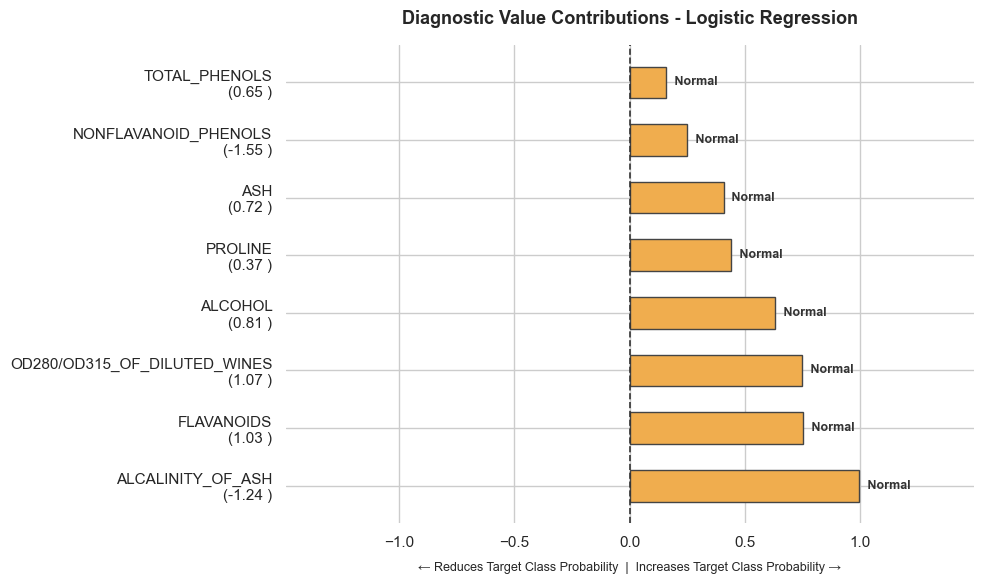


3. Deep Learning Model (Keras)
التقرير التشخيصي الاستشاري المساعد لبيانات المريض
 التشخيص المرجح من النموذج: « class_2 »
 العمر: 67 | الجنس: male | الأمراض المصاحبة: diabetes
 فحص المؤشرات المؤثرة:
  - عوامل خطورة عالية الأثر: 0
  - مؤشرات مطمئنة عالية التأثير: 1
  - مؤشرات متوسطة التأثير: 7
  - مؤشرات طفيفة الأثر: 5


 تحليل المعطيات الحيوية والمخبرية للمريض:
• مؤشر 'Proanthocyanins' بقيمته الحالية (0.08936052953773595 ) ذو تأثير محدود وغير حاسم في مسار القرار السريري الحالي.
• مؤشر 'Color Intensity' بقيمته الحالية (0.018252227969785845 ) ذو تأثير محدود وغير حاسم في مسار القرار السريري الحالي.
• مؤشر 'Magnesium' بقيمته الحالية (1.0655672175876454 ) ذو تأثير محدود وغير حاسم في مسار القرار السريري الحالي.
• مؤشر 'Flavanoids' بقيمته الحالية (1.0272423668544342 ) ذو تأثير محدود وغير حاسم في مسار القرار السريري الحالي.
• مؤشر 'Alcalinity Of Ash' بقيمته الحالية (-1.2412803551326739 ) ذو تأثير محدود وغير حاسم في مسار القرار السريري الحالي.
• يظهر مؤشر 'Ash' بقيمته المسجلة (0.715785790706214

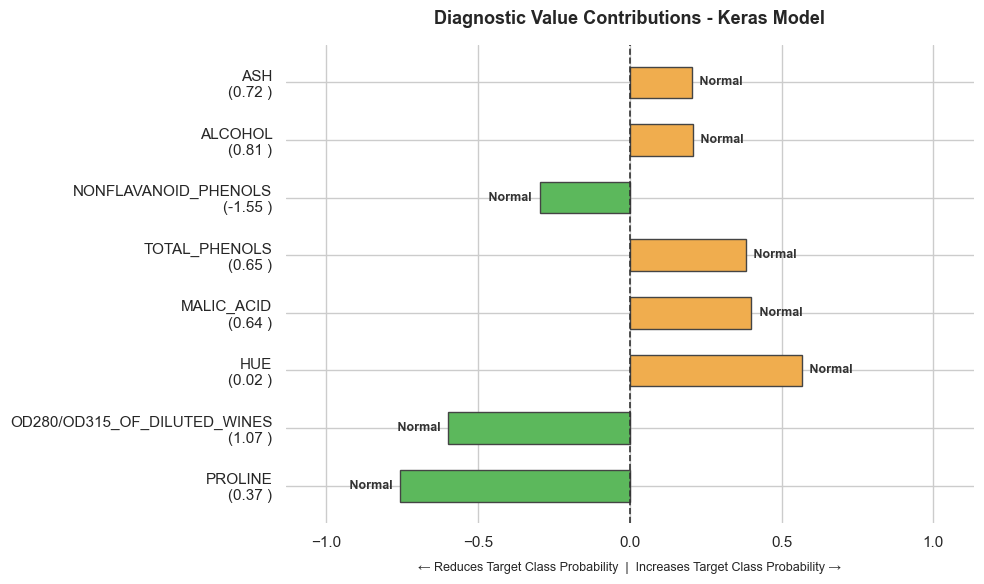

In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

from shap_analyzer import analyze_with_shap

from expert_system import (
    generate_arabic_medical_report,
    classify_features_clinical,
    displaychart,
    display_interactiveChart
)

def main():
    data = load_wine(as_frame=True)
    X, y = data.data, data.target
    class_names = list(data.target_names)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)
    sample_idx = 0

    patient_context = {
        "age": 67,
        "gender": "male",
        "comorbidities": ["diabetes"]
    }

    print("==================================================")
    print("1. Tree-Based Model (RandomForestClassifier)")
    print("==================================================")
    model_tree = RandomForestClassifier(n_estimators=100, random_state=42)
    model_tree.fit(X_train, y_train)
    
    shap_dict, sample_dict, pred = analyze_with_shap(
        model_tree, X_train, X_test.iloc[[sample_idx]]
    )
    report_tree = generate_arabic_medical_report(
        shap_dict, sample_dict, pred, 
        patient_context=patient_context, 
        class_names=class_names
    )
    print(report_tree)
    print("\n[Generating Charts for RandomForestClassifier...]")
    classified_tree = classify_features_clinical(shap_dict, sample_dict, patient_context)
    displaychart(classified_tree, "RandomForest Classifier")
    display_interactiveChart(classified_tree, "RandomForest Classifier")

    print("\n" + "==================================================")
    print("2. Linear Model (Logistic Regression)")
    print("==================================================")
    model_gen = LogisticRegression(max_iter=1000)
    model_gen.fit(X_train_scaled, y_train)
    
    shap_dict, sample_dict, pred = analyze_with_shap(
        model_gen, X_train_scaled, X_test_scaled.iloc[[sample_idx]]
    )
    report_linear = generate_arabic_medical_report(
        shap_dict, sample_dict, pred, 
        patient_context=patient_context, 
        class_names=class_names
    )
    print(report_linear)
    print("\n[Generating Charts for Logistic Regression...]")
    classified_linear = classify_features_clinical(shap_dict, sample_dict, patient_context)
    displaychart(classified_linear, "Logistic Regression")
    display_interactiveChart(classified_linear, "Logistic Regression")

    print("\n" + "==================================================")
    print("3. Deep Learning Model (Keras)")
    print("==================================================")
    model_dl = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(16, activation='relu'),
        Dense(3, activation='softmax')
    ])
    model_dl.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
    model_dl.fit(X_train_scaled, y_train, epochs=10, verbose=0)
    
    raw_keras_predict = model_dl.predict
    
    def dl_predict_wrapper(x, **kwargs):
        preds = raw_keras_predict(x, verbose=0)
        return np.argmax(preds, axis=1)
    
    model_dl.predict = dl_predict_wrapper
    model_dl.predict_proba = raw_keras_predict
    
    shap_dict, sample_dict, pred = analyze_with_shap(
        model_dl, X_train_scaled, X_test_scaled.iloc[[sample_idx]]
    )
    report_dl = generate_arabic_medical_report(
        shap_dict, sample_dict, pred, 
        patient_context=patient_context, 
        class_names=class_names
    )
    print(report_dl)
    
    print("\n[Generating Charts for Keras Deep Learning Model...]")
    classified_dl = classify_features_clinical(shap_dict, sample_dict, patient_context)
    displaychart(classified_dl, "Keras Model")
    display_interactiveChart(classified_dl, "Keras Model")
    print("==================================================")

if __name__ == "__main__":
    main()